# Budowanie, trenowanie i testowanie modelu

In [46]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path

# Dodanie dźwięku przy długich komórkach
import subprocess
def play_sound():
    sound_file = '/mnt/d/Backup/INZ/msg.ogg'
    subprocess.run(['ffplay', '-nodisp', '-autoexit', sound_file], capture_output=True)

Wczytanie odpowiednich danych

In [36]:
SAVE_DIR = Path("/mnt/d/Backup/MAGISTERSKIE/outputs/MODEL")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [37]:
df = pd.read_csv(str(SAVE_DIR)+'/df_training.csv')
ds = df.to_numpy()

# Wstępne Przetwarzanie Danych

Rozdzielenie danych na wejściowe i wyjściowe

In [38]:
x_ds = ds[:, 0:17] # 17 danych - 3*3Δxyz + 6*dJ + 2*dG
y_ds = ds[:, 17:]  # 8  danych - 6*pred_dJ + 2*pred_dG
print(x_ds.shape)
print(y_ds.shape)
print(x_ds[0])
print(y_ds[0])

(7812, 17)
(7812, 8)
[ 0.88793552 -0.54713482 -1.7142334   0.24522633  0.16836209 -0.09461975
  0.06873373 -0.36582538 -0.40885925  3.423105    1.230969    1.932432
  1.527801    1.58762     2.663374    0.603365    0.905047  ]
[-0.000294  0.000588  0.000294 -0.000527  0.001726 -0.002205 -0.005113
  0.      ]


Rozdzielenie danych na treningowe i testowe

In [39]:
rand = np.random.permutation(len(x_ds))
x_ds_shuffled = x_ds[rand]
y_ds_shuffled = y_ds[rand]

split_idx = int(len(x_ds_shuffled) * 0.9)
x_train = x_ds_shuffled[:split_idx]
x_test = x_ds_shuffled[split_idx:]
y_train = y_ds_shuffled[:split_idx]
y_test = y_ds_shuffled[split_idx:]

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

print(x_train[0])
print(x_test[0])

(7030, 17)
(782, 17)
(7030, 8)
(782, 8)
[  5.82265929 -20.67782846  23.2742157    3.36439998 -15.83431878
  26.73928833   5.27825839 -17.54043541  15.19256592   3.111521
   1.591545     2.156014     0.948148     1.593036     2.346703
   0.777216     0.726083  ]
[-51.16822123 -13.38440213 -11.21755981 -43.48086984 -13.12734064
 -15.6885376  -36.14840179 -15.40666491 -11.59007263   3.328001
   1.485948     2.129404     1.076475     1.589633     2.567452
   0.787442     0.72097   ]


Normalizowanie danych

In [40]:
#"""
x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)

x_train = (x_train - x_train_mean) / x_train_std
x_test = (x_test - x_train_mean) / x_train_std

y_train_mean = np.mean(y_train, axis=0)
y_train_variance = np.var(y_train, axis=0)

print(x_train[0])
print(x_test[0])
#""";

[-0.01214963 -0.32296345  0.96274124 -0.02862327 -0.2025366   0.86005262
 -0.00958462 -0.24500185  0.57256285 -1.05407674 -0.91371326  1.35593905
 -1.32396286  0.75203439 -0.71376077  1.29697627 -1.26320609]
[-0.7351408  -0.17882149 -0.58391497 -0.58985992 -0.15298451 -0.65395756
 -0.54791088 -0.2058863  -0.51531648 -0.3146446  -1.27791644  1.27951124
 -0.48876234  0.47235369 -0.33521563  1.33811028 -1.28210416]


Sprawdzenie histogramów danych

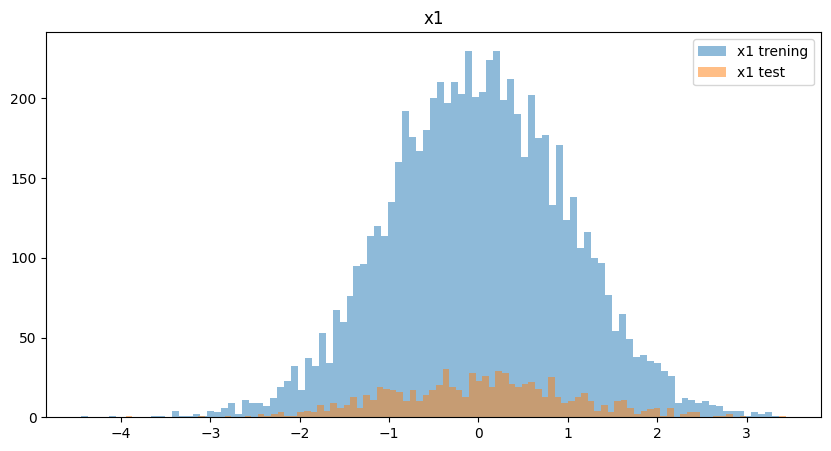

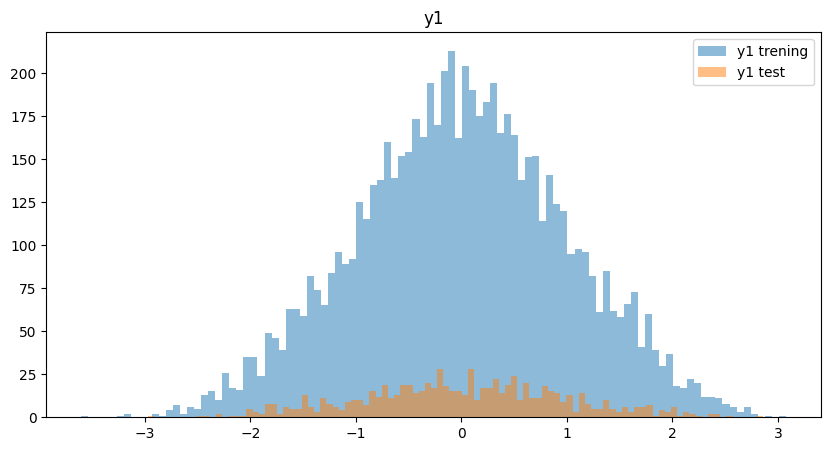

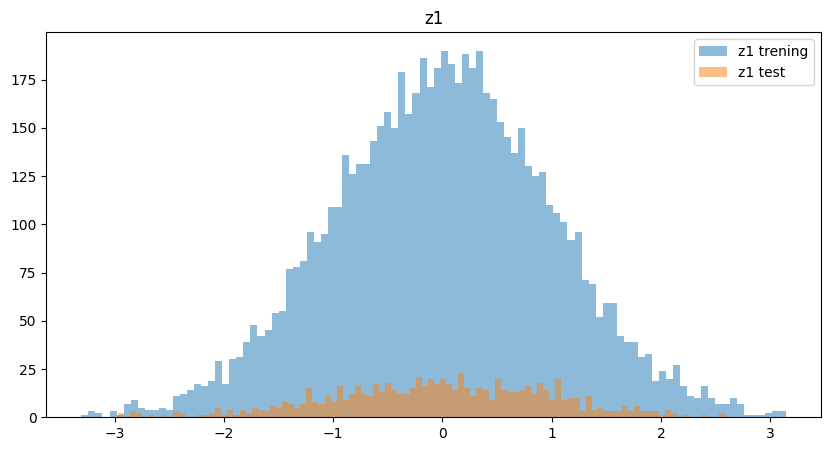

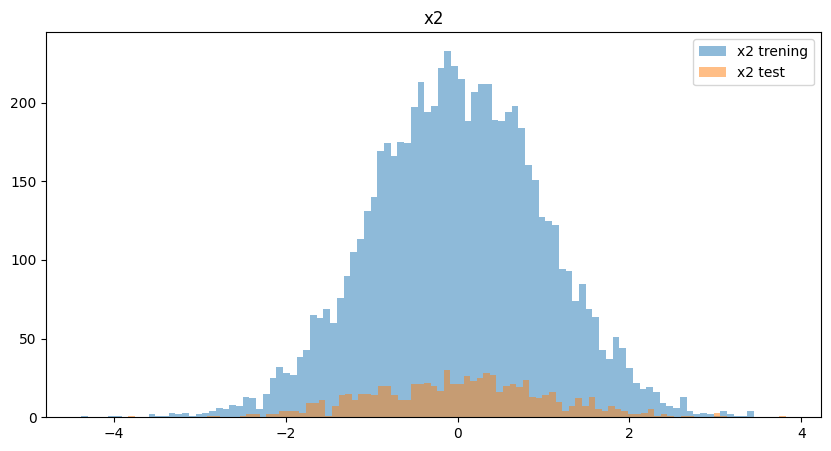

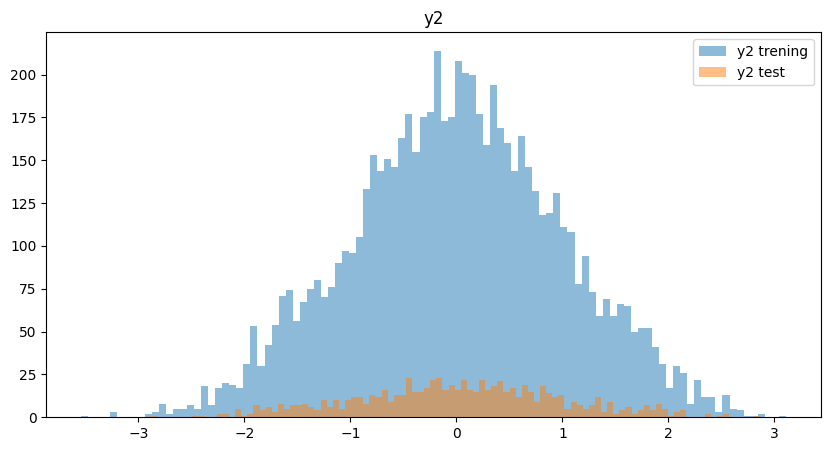

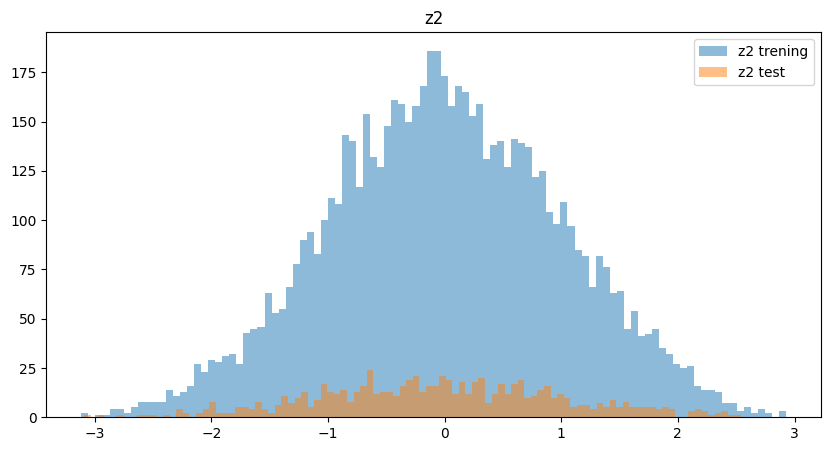

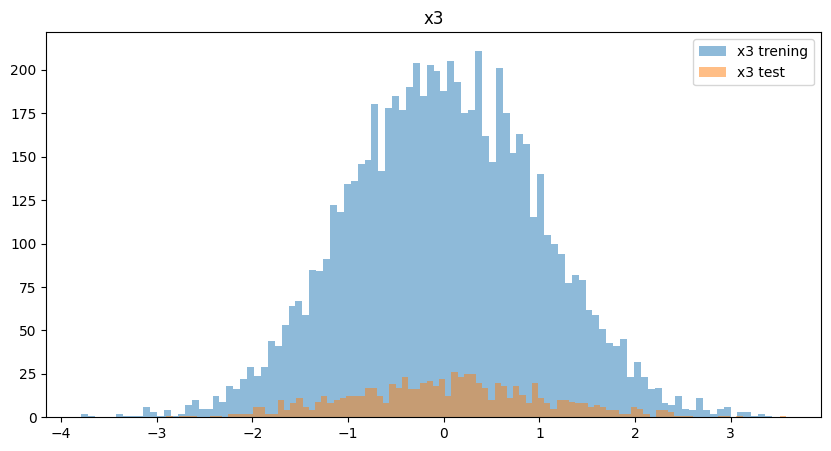

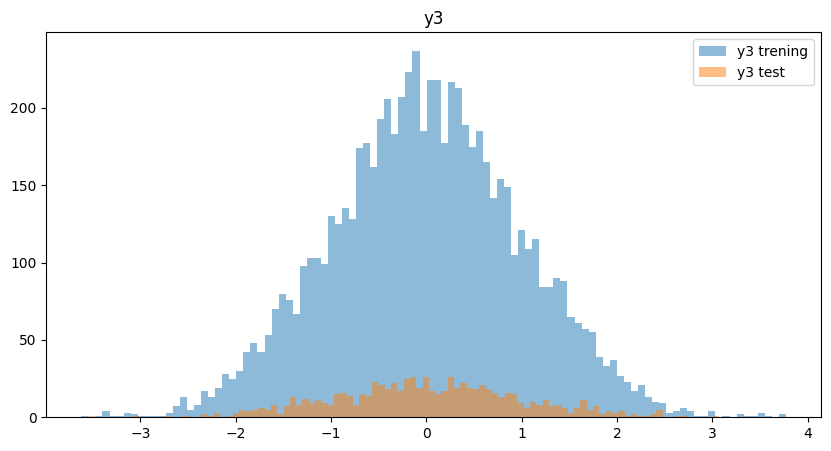

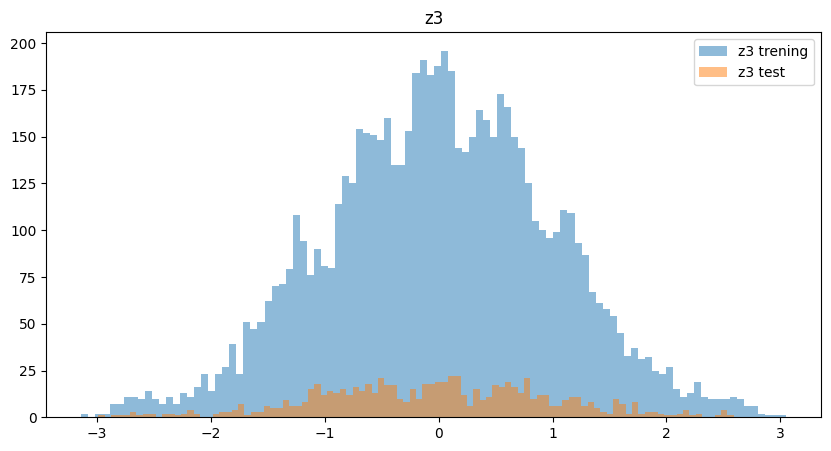

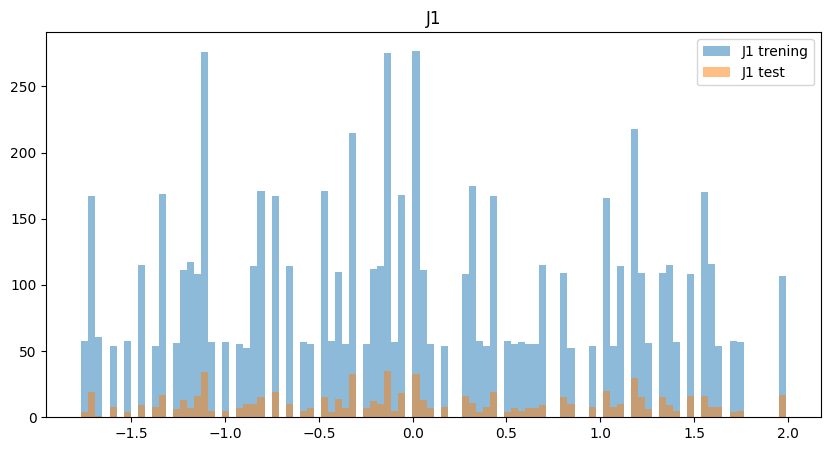

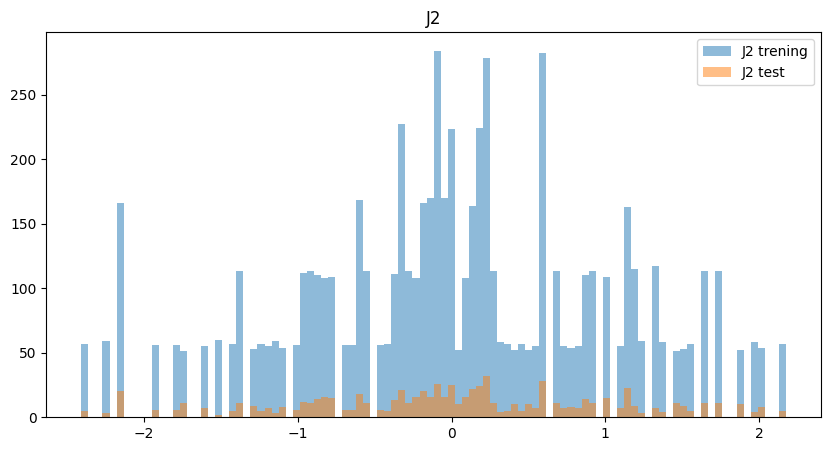

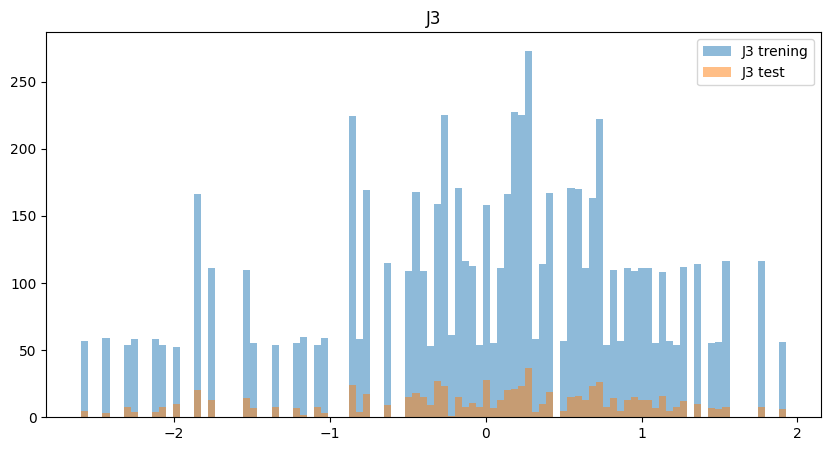

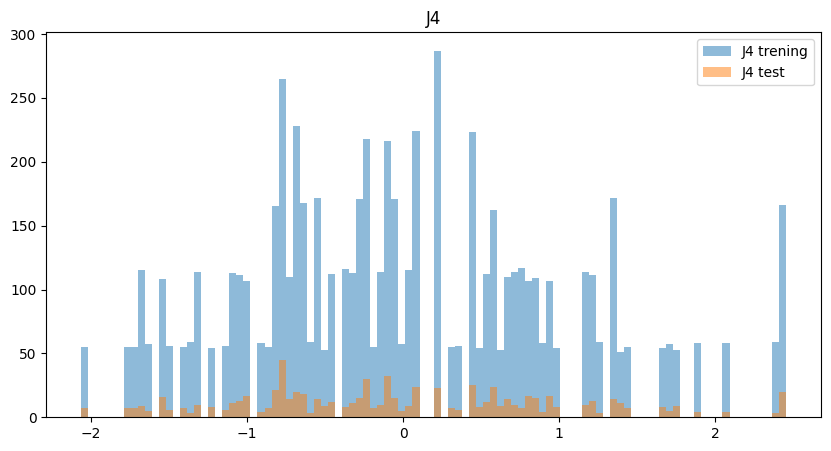

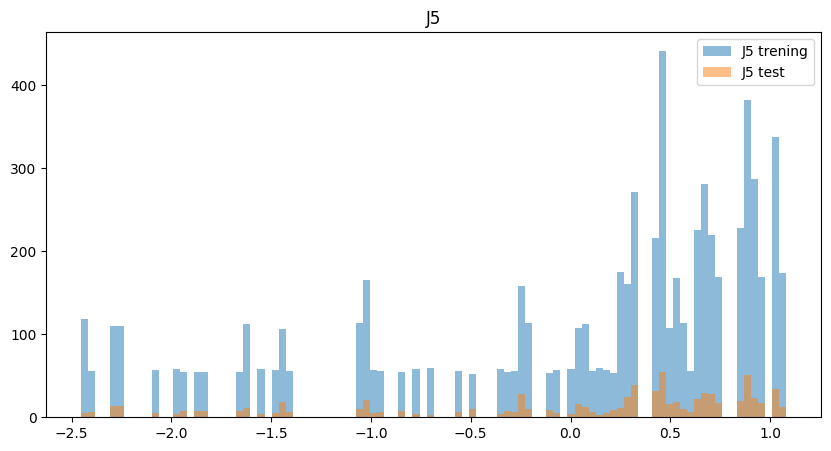

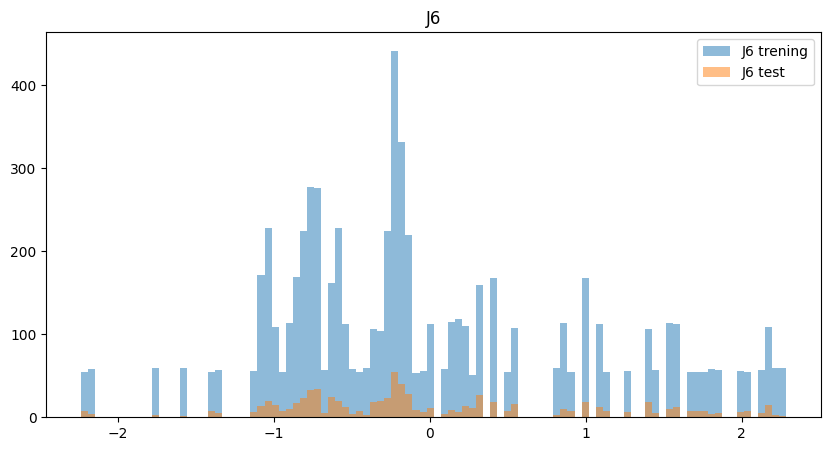

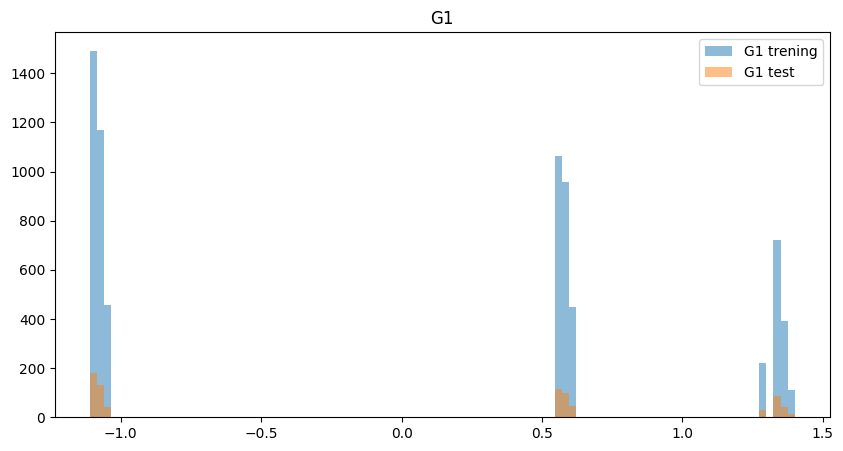

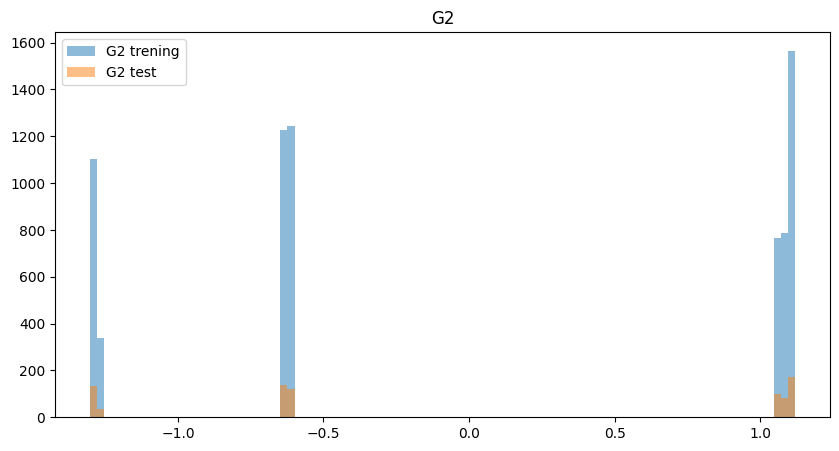

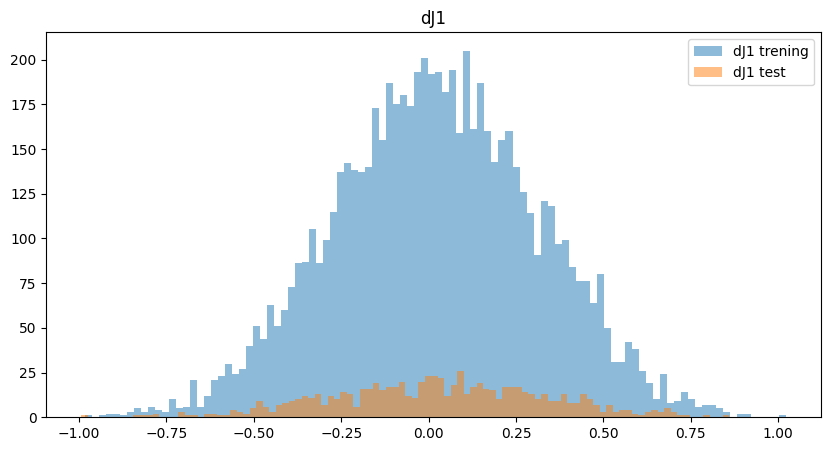

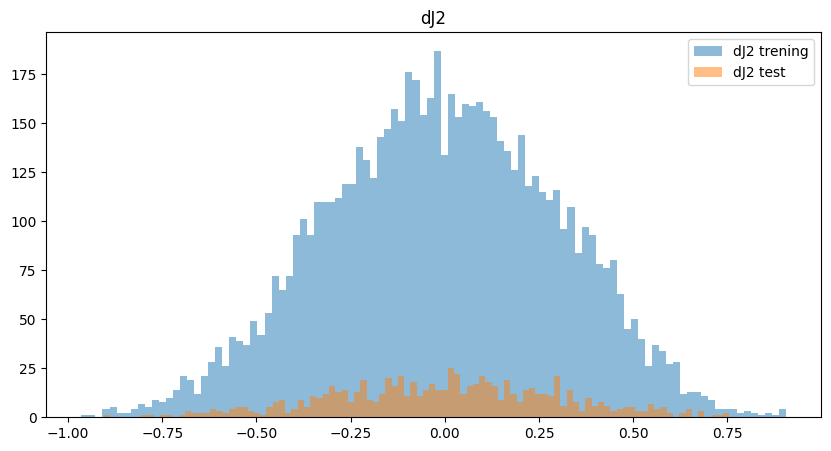

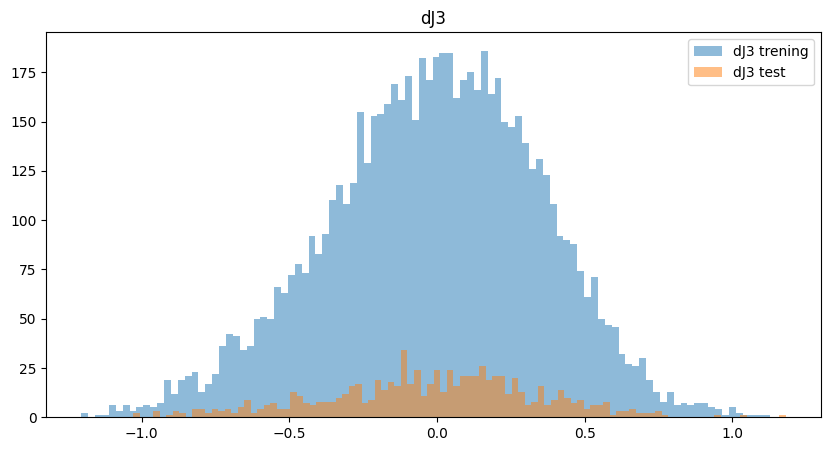

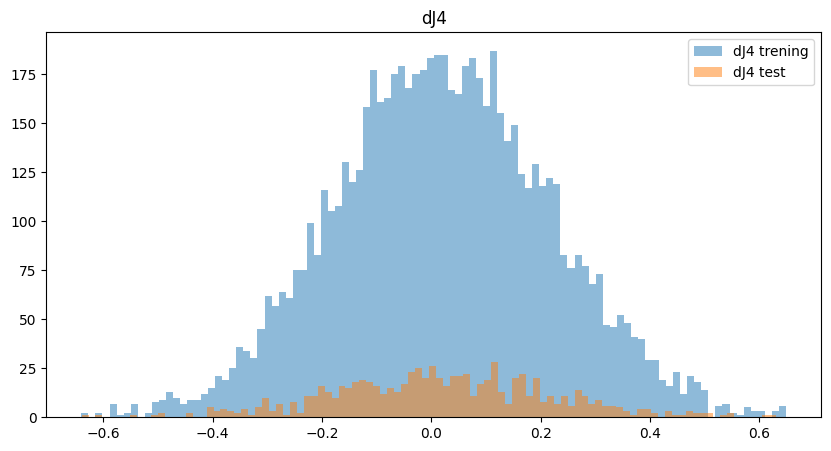

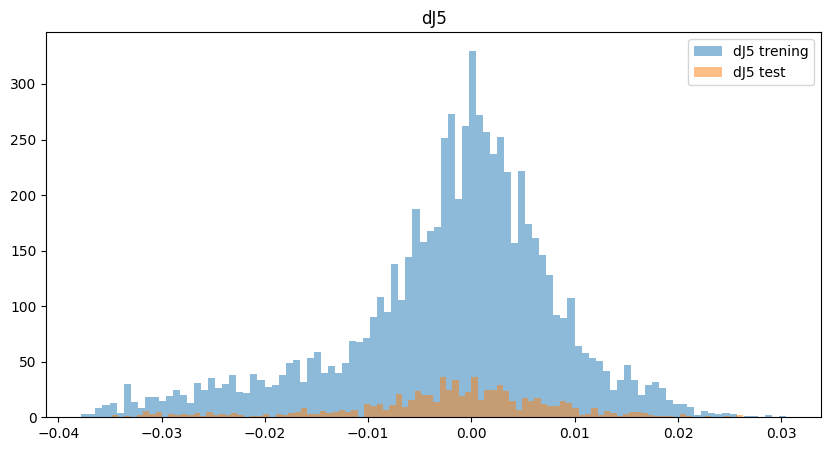

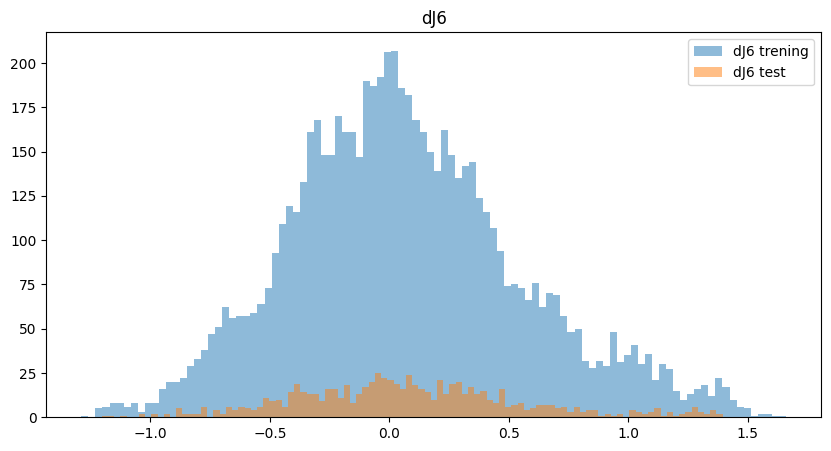

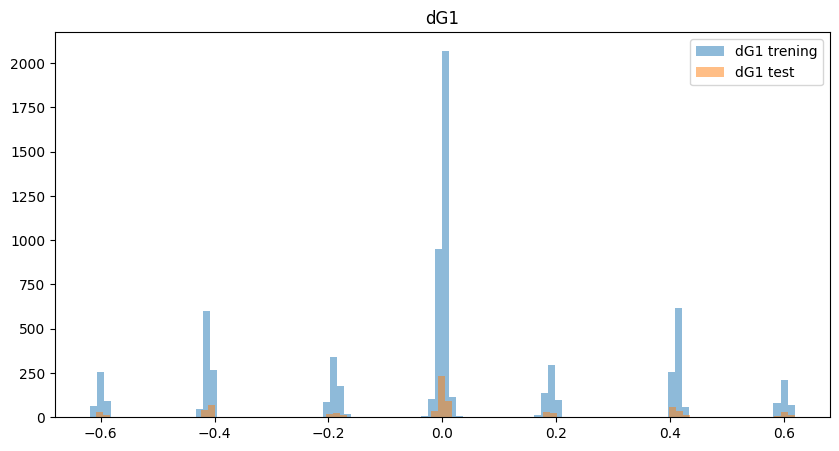

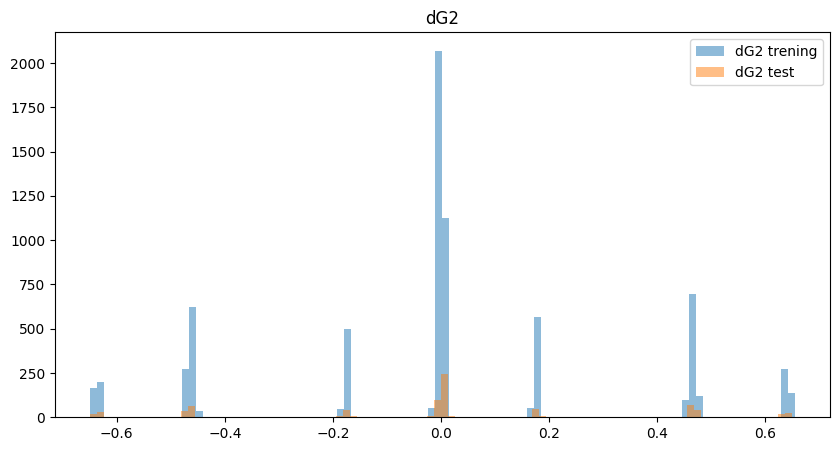

In [41]:
for i in range(x_train.shape[1]):
  plt.figure(figsize=(10, 5))
  plt.hist(x_train[:, i], bins=100, alpha=0.5, label=str(df.columns[i] + ' trening'))
  plt.hist(x_test[:, i], bins=100, alpha=0.5, label=str(df.columns[i] + ' test'))
  plt.title(df.columns[i])
  # plt.xlabel(df.columns[i])
  # plt.ylabel('Frequency')
  plt.legend()
  plt.show()

for i in range(y_train.shape[1]):
  plt.figure(figsize=(10, 5))
  plt.hist(y_train[:, i], bins=100, alpha=0.5, label=str(df.columns[i+x_train.shape[1]] + ' trening'))
  plt.hist(y_test[:, i], bins=100, alpha=0.5, label=str(df.columns[i+x_train.shape[1]] + ' test'))
  plt.title(df.columns[i+x_train.shape[1]])
  # plt.xlabel(df.columns[i+x_train.shape[1]])
  # plt.ylabel('Frequency')
  plt.legend()
  plt.show()

# Tworzenie i Konfiguracja Modelu

Podstawowe parametry modelu

In [42]:
OUTPUTS_PATH = Path("/mnt/d/Backup/MAGISTERSKIE/outputs/MODEL/model_outputs")
MODEL_PATH = Path("/mnt/d/Backup/MAGISTERSKIE/outputs/MODEL/model")

OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)
MODEL_PATH.mkdir(parents=True, exist_ok=True)

input_shape = x_train.shape[-1]
output_shape = y_train.shape[-1]
print(f"input_shape: {input_shape}, output_shape: {output_shape}")

input_shape: 17, output_shape: 8


Lista callback do uczenia

In [43]:
callbacks_list = [
  tf.keras.callbacks.ModelCheckpoint(
    filepath=str(MODEL_PATH)+'/saved_model.keras',
    monitor='val_loss',
    save_best_only=True
  ),
  tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=6,
    verbose=True
  ),
  tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
  )]

## Wariant 1 - Budowanie modelu ręcznie

Parametry modelu

In [44]:
neurons = 320
dropout = 0.1

In [45]:
"""
inputs = tf.keras.Input(shape=(input_shape,))

# augmentacja
#x = tf.keras.layers.GaussianNoise(0.1)(inputs)

x = tf.keras.layers.Dense(neurons, activation='relu', activity_regularizer=tf.keras.regularizers.l2(1e-4))(inputs)
x = tf.keras.layers.BatchNormalization()(x)
#x = tf.keras.layers.Dropout(dropout/2)(x)

# Pierwszy blok residual
x_skip = x
x = tf.keras.layers.Dense(neurons*2, activation='relu', activity_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
#x = tf.keras.layers.Dropout(dropout)(x)
x = tf.keras.layers.Dense(neurons, activation='relu', activity_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Add()([x, x_skip])

# Drugi blok residual
x_skip = x
x = tf.keras.layers.Dense(neurons*2, activation='relu', activity_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
#x = tf.keras.layers.Dropout(dropout)(x)
x = tf.keras.layers.Dense(neurons, activation='relu', activity_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Add()([x, x_skip])

outputs_normalized = tf.keras.layers.Dense(output_shape, name='normalized_dense')(x)

outputs = tf.keras.layers.Normalization(
    mean=y_train_mean, 
    variance=y_train_variance, 
    invert=True, 
    name='denormalization'
)(outputs_normalized)

model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.summary()
#""";

## Wariant 2 - Budowanie modelu za pomocą tunera

In [ ]:
"""
import keras_tuner as kt

input_shape = x_train.shape[-1]
output_shape = y_train.shape[-1]

def build_model(hp):
    hp: kt.HyperParameters
    
    num_blocks = hp.Int('num_blocks', min_value=4, max_value=8, step=1)
    neurons = hp.Int('neurons', min_value=64, max_value=640, step=64)
    learning_rate = hp.Float('learning_rate', min_value=1e-5, max_value=1e-2, sampling='log')
    
    inputs = tf.keras.Input(shape=(input_shape,))
    x = inputs
    x = tf.keras.layers.Dense(neurons, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    
    for i in range(num_blocks):
        x_skip = x
        x = tf.keras.layers.Dense(neurons*2, activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Dropout(0.1)(x)
        x = tf.keras.layers.Dense(neurons, activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Add()([x, x_skip])
    
    outputs_normalized = tf.keras.layers.Dense(output_shape, name='normalized_dense')(x)
    outputs = tf.keras.layers.Normalization(mean=y_train_mean, variance=y_train_variance, invert=True, name='denormalization')(outputs_normalized)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.MeanSquaredError(),
        metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=16,
    executions_per_trial=1,
    #directory='ktuner_dir',
    project_name='diff_pred_tuning'
)

tuner.search(x_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=callbacks_list)
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best number of blocks:", best_hp.get('num_blocks'))
print("Best neurons:", best_hp.get('neurons'))
print("Best learning rate:", best_hp.get('learning_rate'))

play_sound()
#"""

Trial 16 Complete [00h 00m 26s]
val_loss: 0.10651502758264542

Best val_loss So Far: 0.0014951841440051794
Total elapsed time: 00h 49m 40s
Best number of blocks: 7
Best neurons: 128
Best learning rate: 0.005125626297102766


Tworzenie szkieletu modelu i zapisanie do pliku

In [ ]:
# model = build_model(best_hp)
# model.save(str(MODEL_PATH)+"/new_model_tuned.keras")

# Proces Uczenia

Odczytanie znalezionego szkieletu modelu

In [7]:
model = tf.keras.models.load_model("model_tuned.keras")

2025-06-17 12:09:03.904287: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-06-17 12:09:04.188621: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/ruszczka/projekty/test_files/.venv/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 142 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
"""
base_learning_rate = 1e-2
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    base_learning_rate,
    decay_steps=2318,
    decay_rate=0.8,
    staircase=True)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
              loss= tf.keras.losses.MeanSquaredError(),
              metrics = [tf.keras.metrics.RootMeanSquaredError()])
#""";

Proces uczenia

In [ ]:
history = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=256,
    callbacks=callbacks_list
)
play_sound()

Epoch 1/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 69ms/step - loss: 1.1856 - root_mean_squared_error: 1.0466 - val_loss: 0.4110 - val_root_mean_squared_error: 0.6411 - learning_rate: 0.0051
Epoch 2/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0713 - root_mean_squared_error: 0.2669 - val_loss: 0.1545 - val_root_mean_squared_error: 0.3931 - learning_rate: 0.0051
Epoch 3/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0453 - root_mean_squared_error: 0.2128 - val_loss: 0.0906 - val_root_mean_squared_error: 0.3011 - learning_rate: 0.0051
Epoch 4/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0368 - root_mean_squared_error: 0.1918 - val_loss: 0.0672 - val_root_mean_squared_error: 0.2592 - learning_rate: 0.0051
Epoch 5/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0320 - root_mean_squared_error: 0.1788 - val_loss: 0.0581 - val_root_mean_squared_error: 0.2410 - learning_rate: 0.0051
Epoch 6/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0274 - root_mean_squared_er

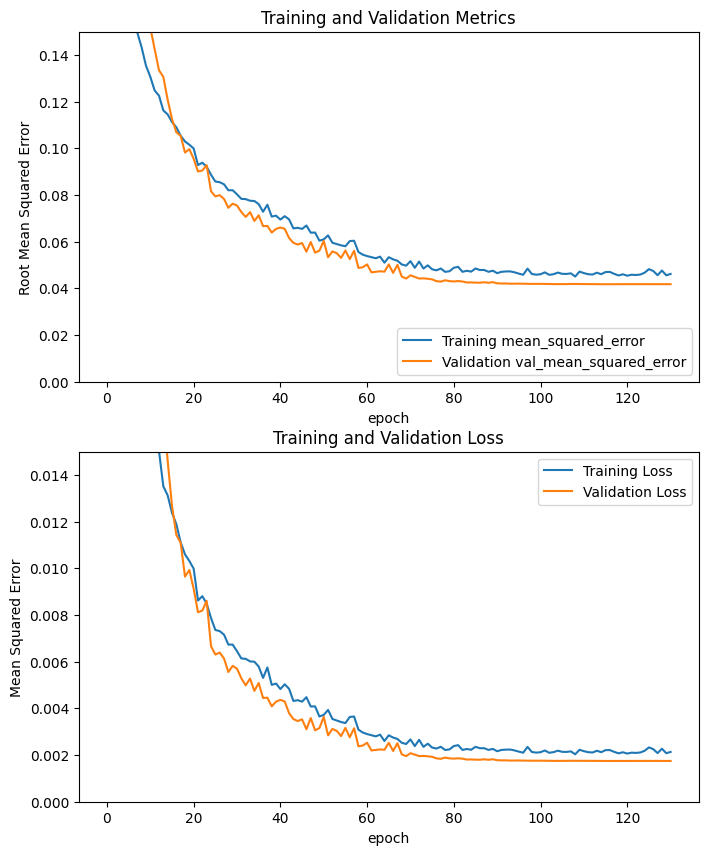

In [51]:
root_mean_squared_error = history.history['root_mean_squared_error']
val_root_mean_squared_error = history.history['val_root_mean_squared_error']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 1)
plt.plot(root_mean_squared_error, label='Training mean_squared_error')
plt.plot(val_root_mean_squared_error, label='Validation val_mean_squared_error')
plt.legend(loc='lower right')
plt.ylabel('Root Mean Squared Error')
plt.ylim(0.00,0.15)
plt.title('Training and Validation Metrics')
plt.xlabel('epoch')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Mean Squared Error')
plt.ylim(0.000,0.015)
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.savefig(str(OUTPUTS_PATH)+'/fig.png')

In [52]:
model.evaluate(x=x_test, y=y_test, batch_size=256, verbose=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0018 - root_mean_squared_error: 0.0419


[0.0016901562921702862, 0.04111151024699211]

## Testowanie uzyskanego modelu

Zapisanie wyników predykcji

In [53]:
result = model.predict(x=x_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


Wyświetlenie błędów na poszczególnych przegubach

In [54]:
diff_test = np.rad2deg(np.mean(np.abs(result-y_test), axis=0))

joints_error_dict = dict(zip(df.columns[17:], diff_test))
for joint, error in joints_error_dict.items():
    print(f"{joint}: {error:.2f} stopni")

dJ1: 0.93 stopni
dJ2: 0.96 stopni
dJ3: 1.57 stopni
dJ4: 1.21 stopni
dJ5: 0.10 stopni
dJ6: 3.13 stopni
dG1: 1.89 stopni
dG2: 2.00 stopni


Wyświetlenie średniej i mediane błędu absolutnego

In [55]:
mean_test = np.rad2deg(np.mean(np.abs(result-y_test)))
median_test = np.rad2deg(np.median(np.abs(result-y_test)))

print(f"Średnia: {mean_test:.2f} stopni")
print(f"Mediana: {median_test:.2f} stopni")

Średnia: 1.47 stopni
Mediana: 0.91 stopni


## Zapisanie wyników do pliku .csv

In [56]:
cols = [ 'J1', 'J2', 'J3', 'J4', 'J5', 'J6', 'G1', 'G2',
        'dJ1', 'dJ2', 'dJ3', 'dJ4', 'dJ5', 'dJ6', 'dG1', 'dG2',
        'pred_dJ1', 'pred_dJ2', 'pred_dJ3', 'pred_dJ4', 'pred_dJ5', 'pred_dJ6', 'pred_dG1', 'pred_dG2']

In [57]:
print(result.shape)
print(x_test[:,9:].shape)
print(y_test.shape)

(782, 8)
(782, 8)
(782, 8)


Zapisanie wyników do testowania na robocie

In [58]:
wyniki = pd.concat([pd.DataFrame(x_test[:,9:]*x_train_std[9:]+x_train_mean[9:], columns=cols[:8]),  # Pozycja początkowa
                    pd.DataFrame(y_test, columns=cols[8:16]),                                       # Różnica faktyczna
                    pd.DataFrame(result, columns=cols[16:])], axis=1)                               # Różnica przewidywana
wyniki.to_csv(str(OUTPUTS_PATH)+"/wyniki.csv", index=False, header=True)

In [59]:
wyniki.head(5)

,J1,J2,J3,J4,J5,J6,G1,G2,dJ1,dJ2,...,dG1,dG2,pred_dJ1,pred_dJ2,pred_dJ3,pred_dJ4,pred_dJ5,pred_dJ6,pred_dG1,pred_dG2
0,3.328001,1.485948,2.129404,1.076475,1.589633,2.567452,0.787442,0.720970,-0.281255,-0.118164,...,0.189190,-0.173851,-0.321231,-0.108094,-0.075644,0.182289,0.005784,-0.386600,0.163178,-0.164627
1,4.002371,1.902184,1.520754,1.262949,1.563891,3.686156,0.184077,1.365241,0.396150,-0.121731,...,0.005113,0.005113,0.375738,-0.103922,-0.213044,0.326865,-0.006270,0.254581,0.011771,-0.020870
2,3.168989,1.854412,1.724678,1.116023,1.591934,2.405378,0.189191,1.355014,-0.176108,-0.067881,...,-0.419287,0.455080,-0.169606,-0.093632,-0.135407,0.205817,-0.004443,0.272321,-0.391432,0.437989
3,3.899750,1.891317,1.515663,1.279583,1.580812,3.006794,0.184077,1.370354,-0.028020,-0.137239,...,-0.414175,0.470420,-0.029995,-0.140078,0.019509,0.124747,-0.003671,0.104675,-0.305658,0.352663
4,4.002371,1.902184,1.520754,1.262949,1.563891,3.686156,0.184077,1.365241,0.639145,0.070583,...,-0.010227,0.005113,0.596611,0.043090,-0.104147,0.046355,-0.029265,1.178730,0.009671,0.003789


In [74]:
print("Mniejszy od 1 stopnia:")
for col in cols[8:16]:
    print(f"{col}: {np.sum(np.abs(np.rad2deg(wyniki[col])-np.rad2deg(wyniki['pred_'+col]))<1)} / {len(wyniki)} {np.sum(np.abs(np.rad2deg(wyniki[col])-np.rad2deg(wyniki['pred_'+col]))<1)/len(wyniki)*100:.2f}%")

Mniejszy od 1 stopnia:
dJ1: 501 / 782 64.07%
dJ2: 485 / 782 62.02%
dJ3: 342 / 782 43.73%
dJ4: 395 / 782 50.51%
dJ5: 782 / 782 100.00%
dJ6: 209 / 782 26.73%
dG1: 293 / 782 37.47%
dG2: 299 / 782 38.24%


Histogram otrzymanych wyników

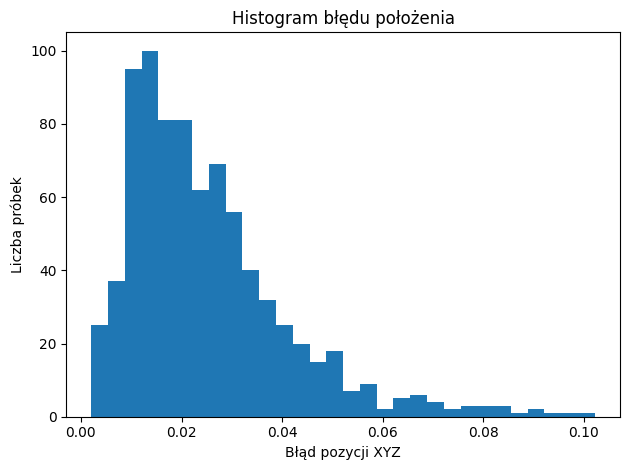

In [63]:
RESULT_PATH = Path("/mnt/c/Users/rados/downloads")

# Załdowanie danych i obliczenie błędów
df_wyniki = pd.read_csv(str(RESULT_PATH)+'/wyniki_vert_converted.csv')
df_wyniki['error_x'] = df_wyniki['x_to_predicted'] - df_wyniki['x_to_ground_truth']
df_wyniki['error_y'] = df_wyniki['y_to_predicted'] - df_wyniki['y_to_ground_truth']
df_wyniki['error_z'] = df_wyniki['z_to_predicted'] - df_wyniki['z_to_ground_truth']
df_wyniki['error_magnitude'] = np.sqrt(df_wyniki[['error_x', 'error_y', 'error_z']].pow(2).sum(axis=1))

# Wyświetlenie histogramu błędu położenia
plt.figure()
plt.hist(df_wyniki['error_magnitude'], bins=30)
plt.title('Histogram błędu położenia')
plt.xlabel('Błąd pozycji XYZ')
plt.ylabel('Liczba próbek')
plt.tight_layout()
plt.show()
